# Multivariable Linear Regression/Dan Kamdem

In [6]:
# load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# This dataset has only 3 columns and 29 rows.
# There are only two independent variables and one dependent variable. 
# The independent variables are 'age' and 'experience'. The dependent variable is 'income'.

In [7]:
# read data
data = pd.read_csv('data/multiple_linear_regression_dataset.csv')
data


,age,experience,income
0,25.0,1,30450.0
1,30.0,3,35670.0
2,47.0,2,31580.0
3,32.0,5,40130.0
4,43.0,10,47830.0
5,NaN,34,NaN
6,10.0,10,47444.0
7,51.0,7,41630.0
8,28.0,5,41340.0
9,33.0,4,37650.0


## Data Cleaning

In [8]:
# 1- Summarize the number of unique values 

import pandas as pd
# define the location of the dataset
path = 'data/multiple_linear_regression_dataset.csv'
# load the dataset using the "read_csv" function from pandas library
df = pd.read_csv(path)
# summarize the number of unique values in each column using the "nunique" function from pandas
print(df.nunique())

age           17
experience    14
income        22
dtype: int64


In [9]:
#2- Look for duplicated rows
df[df.duplicated()]

,age,experience,income
22,37.0,10,48700.0
23,41.0,6,38900.0
24,23.0,1,30870.0
25,51.0,4,34800.0
26,47.0,9,46110.0


In [10]:
#3- Detete duplicated rows
df = df.drop_duplicates()
df

,age,experience,income
0,25.0,1,30450.0
1,30.0,3,35670.0
2,47.0,2,31580.0
3,32.0,5,40130.0
4,43.0,10,47830.0
5,NaN,34,NaN
6,10.0,10,47444.0
7,51.0,7,41630.0
8,28.0,5,41340.0
9,33.0,4,37650.0


In [11]:
#4- Check for missing values
df.isnull().sum()

age           3
experience    0
income        2
dtype: int64

In [12]:
#5- Delete rows that contain missing values
df = df.dropna()
df

,age,experience,income
0,25.0,1,30450.0
1,30.0,3,35670.0
2,47.0,2,31580.0
3,32.0,5,40130.0
4,43.0,10,47830.0
6,10.0,10,47444.0
7,51.0,7,41630.0
8,28.0,5,41340.0
9,33.0,4,37650.0
10,37.0,5,40250.0


## Data Visualization

<Axes: title={'center': 'Age/Xp vs Incomes'}, xlabel='age', ylabel='income'>

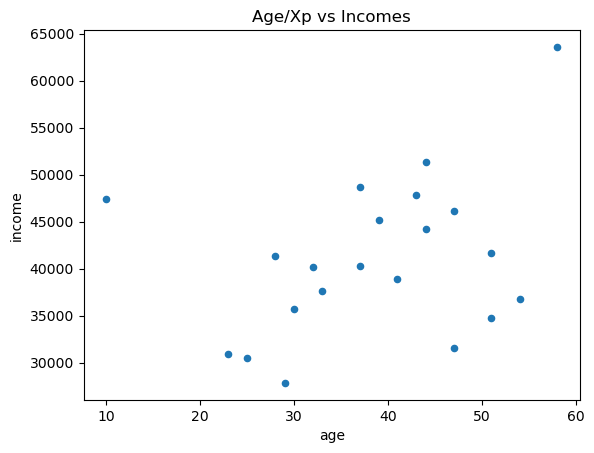

In [13]:
# Scatter Plot
df.plot.scatter(x='age', y='income', title='Age/Xp vs Incomes')

<Axes: title={'center': 'Iris Dataset'}>

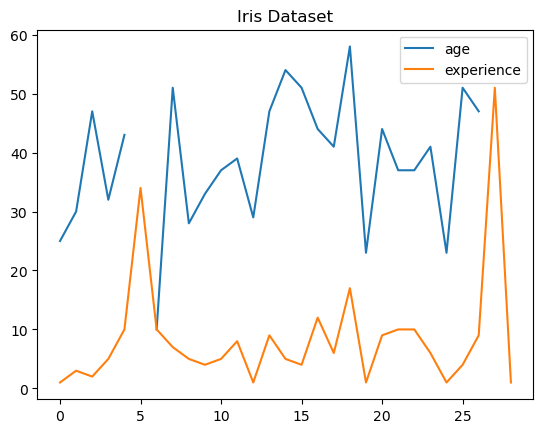

In [14]:
# Line Chart
data.drop(['income'], axis=1).plot.line(title='Iris Dataset')

<Axes: ylabel='Frequency'>

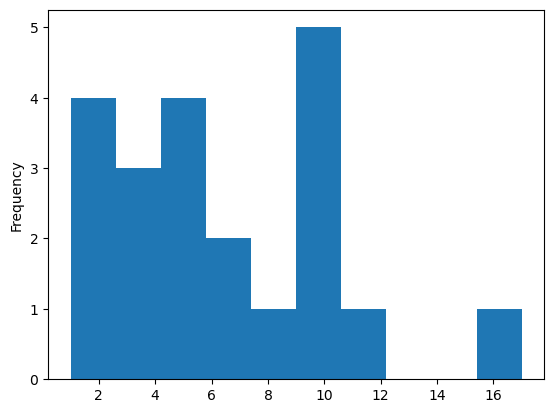

In [15]:
# Histogram with experience
df['experience'].plot.hist()

<Axes: ylabel='Frequency'>

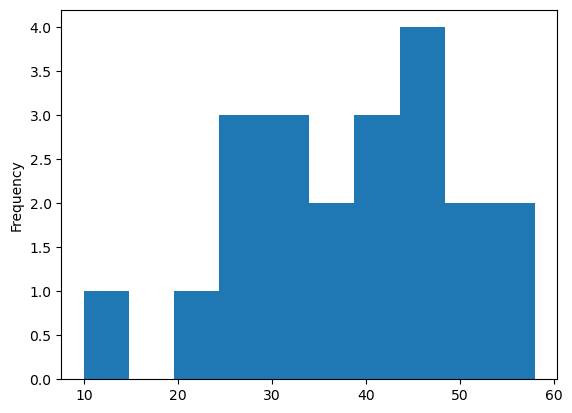

In [16]:
# Histogram with age
df['age'].plot.hist()

<Axes: xlabel='age'>

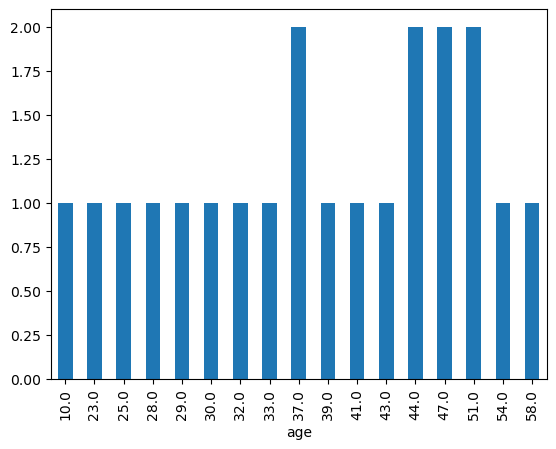

In [17]:
# Bar Chart with age

# Count column 'age' values numbers occurrences 
age = df['age'].value_counts()
# Sort points indices by ascending using 
age = age.sort_index()
# Plot points 
age.plot.bar()

<Axes: ylabel='experience'>

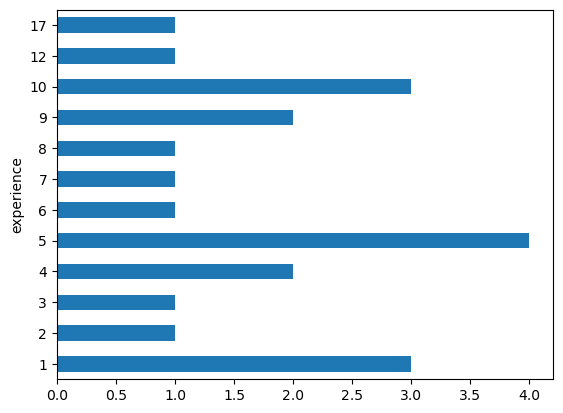

In [18]:
# Bar Chart with experience

# Count column 'experience' values numbers occurrences 
experience = df['experience'].value_counts()
# Sort points indices by ascending using 
experience = experience.sort_index()
# Plot points 
experience.plot.barh()

## Linear regression from Scratch

In [19]:
# Read data
data = df.to_numpy()
print(data)

[[2.5000e+01 1.0000e+00 3.0450e+04]
 [3.0000e+01 3.0000e+00 3.5670e+04]
 [4.7000e+01 2.0000e+00 3.1580e+04]
 [3.2000e+01 5.0000e+00 4.0130e+04]
 [4.3000e+01 1.0000e+01 4.7830e+04]
 [1.0000e+01 1.0000e+01 4.7444e+04]
 [5.1000e+01 7.0000e+00 4.1630e+04]
 [2.8000e+01 5.0000e+00 4.1340e+04]
 [3.3000e+01 4.0000e+00 3.7650e+04]
 [3.7000e+01 5.0000e+00 4.0250e+04]
 [3.9000e+01 8.0000e+00 4.5150e+04]
 [2.9000e+01 1.0000e+00 2.7840e+04]
 [4.7000e+01 9.0000e+00 4.6110e+04]
 [5.4000e+01 5.0000e+00 3.6720e+04]
 [5.1000e+01 4.0000e+00 3.4800e+04]
 [4.4000e+01 1.2000e+01 5.1300e+04]
 [4.1000e+01 6.0000e+00 3.8900e+04]
 [5.8000e+01 1.7000e+01 6.3600e+04]
 [2.3000e+01 1.0000e+00 3.0870e+04]
 [4.4000e+01 9.0000e+00 4.4190e+04]
 [3.7000e+01 1.0000e+01 4.8700e+04]]


In [20]:
# Seperate them into X and y
X = data[:, :2]
print(X)

[[25.  1.]
 [30.  3.]
 [47.  2.]
 [32.  5.]
 [43. 10.]
 [10. 10.]
 [51.  7.]
 [28.  5.]
 [33.  4.]
 [37.  5.]
 [39.  8.]
 [29.  1.]
 [47.  9.]
 [54.  5.]
 [51.  4.]
 [44. 12.]
 [41.  6.]
 [58. 17.]
 [23.  1.]
 [44.  9.]
 [37. 10.]]


In [21]:
y = data[:, 2:3]
print(y)

[[30450.]
 [35670.]
 [31580.]
 [40130.]
 [47830.]
 [47444.]
 [41630.]
 [41340.]
 [37650.]
 [40250.]
 [45150.]
 [27840.]
 [46110.]
 [36720.]
 [34800.]
 [51300.]
 [38900.]
 [63600.]
 [30870.]
 [44190.]
 [48700.]]


In [22]:
# Normalized data: 1 subtract the mean; 2 divide the standard deviation
X_mean = np.mean(X,0)
X_normalized= X - X_mean
X_std= np.std(X,0)
X_normalized /= X_std

# Add an additional column as 1 for X
m = y.size
X_normalized = np.c_[np.ones(m),X_normalized]

In [23]:
X_mean = np.mean(X,0)
X_mean

array([38.23809524,  6.38095238])

In [24]:
X_std

array([11.43888424,  4.00566492])

In [25]:
X_normalized

array([[ 1.        , -1.15728903, -1.34333562],
       [ 1.        , -0.72018346, -0.84404274],
       [ 1.        ,  0.76597547, -1.09368918],
       [ 1.        , -0.54534123, -0.34474985],
       [ 1.        ,  0.41629102,  0.90348237],
       [ 1.        , -2.46860574,  0.90348237],
       [ 1.        ,  1.11565993,  0.15454304],
       [ 1.        , -0.89502569, -0.34474985],
       [ 1.        , -0.45792012, -0.59439629],
       [ 1.        , -0.10823566, -0.34474985],
       [ 1.        ,  0.06660656,  0.40418948],
       [ 1.        , -0.80760457, -1.34333562],
       [ 1.        ,  0.76597547,  0.65383592],
       [ 1.        ,  1.37792327, -0.34474985],
       [ 1.        ,  1.11565993, -0.59439629],
       [ 1.        ,  0.50371213,  1.40277525],
       [ 1.        ,  0.24144879, -0.09510341],
       [ 1.        ,  1.72760772,  2.65100747],
       [ 1.        , -1.33213126, -1.34333562],
       [ 1.        ,  0.50371213,  0.65383592],
       [ 1.        , -0.10823566,  0.903

In [26]:
# Cost function
def computeCost(X,y,theta):
    m=y.size
    h=X.dot(theta)
    J=1/(2*m)*np.sum((h-y)**2)
    return(J)

In [27]:
computeCost(X_normalized,y,[[0],[0],[0]])

875998234.1904762

In [37]:
# Gradient Descent 
def gradientDescent(X, y, theta, alpha=0.01, num_iters=50):
    m = y.size
    J_history = np.zeros(num_iters)
    theta = theta.copy()
    for i in range(num_iters):
        h = X.dot(theta)
        # The dot product X.T.dot(h-y) already gives the sum of gradients
        gradient = (1/m) * (X.T.dot(h - y))
        theta = theta - alpha * gradient
        J_history[i] = computeCost(X, y, theta)
    return theta, J_history

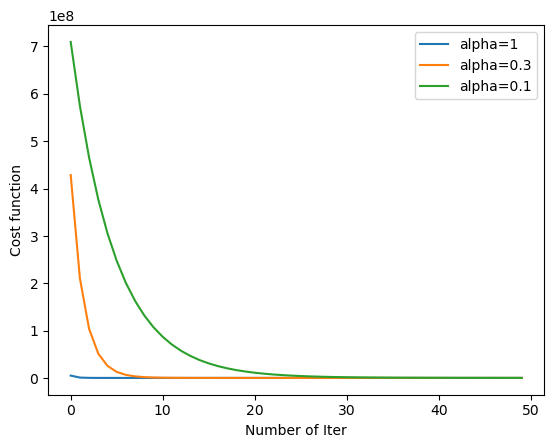

In [38]:
# Run gradient descent
theta1,cost_J1=gradientDescent(X_normalized,y,[[0],[0],[0]],1)
theta2,cost_J2=gradientDescent(X_normalized,y,[[0],[0],[0]],0.3)
theta3,cost_J3=gradientDescent(X_normalized,y,[[0],[0],[0]],0.1)
# Plot
plt.plot(cost_J1,label='alpha=1')
plt.plot(cost_J2,label='alpha=0.3')
plt.plot(cost_J3,label='alpha=0.1')
plt.xlabel('Number of Iter')
plt.ylabel('Cost function')
plt.legend()

In [ ]:
# Predict income for age=40 and experience=10
new_case = np.array([[40, 10]])
new_case_normalized = (new_case - X_mean) / X_std
new_case_final = np.c_[1, new_case_normalized]

prediction = new_case_final.dot(theta1)
print('Predicted income for age 40, experience 10: $',prediction)

## Linear Regression using Scikit-Learn library

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Initialize the model
model = LinearRegression()

# Fit the model
model.fit(X, y)

# View the parameters
print(f"Intercept (theta 0): {model.intercept_}")
print(f"Coefficients (theta 1, theta 2): {model.coef_}")

# Make a prediction for Age=40, Experience=10
new_case = [[40, 10]]
prediction = model.predict(new_case)
print(f"Predicted income for age 40, experience 10: ${prediction}")

# 5. Calculate the final Cost (MSE / 2)
y_pred = model.predict(X)
final_cost = mean_squared_error(y, y_pred) / 2
print(f"Final Cost: {final_cost}")

Intercept (theta 0): [29435.05901524]
Coefficients (theta 1, theta 2): [[ -37.5001344  2045.74901943]]
Predicted income for age 40, experience 10: $[[48392.54383352]]
Final Cost: 949988.2786168623
